In [2]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 66.7 MB/s eta 0:00:00


In [3]:
import rioxarray

# Open the GeoTIFF file with rioxarray (which preserves geospatial info)
tiff_file = "s1_S1C_IW_GRDH_1SDV_20250528T005124_20250528T005149_002524_00541A_5EE1_2025-05-17_2025-05-31.tif"
data = rioxarray.open_rasterio(tiff_file, masked=True)

# Assign a name to the data variable
data.name = "backscatter"

# Export to NetCDF
netcdf_file = tiff_file.replace(".tif", ".nc")
data.to_netcdf(netcdf_file)

netcdf_file


's1_S1C_IW_GRDH_1SDV_20250528T005124_20250528T005149_002524_00541A_5EE1_2025-05-17_2025-05-31.nc'

In [4]:
!ls -lrt

total 1576
drwxr-xr-x 1 root root    4096 Jun 26 13:35 sample_data
-rw-r--r-- 1 root root  406683 Jul  2 05:26 s1_S1C_IW_GRDH_1SDV_20250528T005124_20250528T005149_002524_00541A_5EE1_2025-05-17_2025-05-31.tif
-rw-r--r-- 1 root root 1199996 Jul  2 05:26 s1_S1C_IW_GRDH_1SDV_20250528T005124_20250528T005149_002524_00541A_5EE1_2025-05-17_2025-05-31.nc


# Read OPERA data

In [15]:
ds_opera = xr.open_dataset('OPERA_L3_DISP-S1_IW_F20698_VV_20210805T005144Z_20211121T005146Z_v1.0_20250418T200307Z.nc')

In [17]:
import xarray as xr
import rioxarray
from rasterio.warp import calculate_default_transform
import numpy as np

# Open dataset and select displacement
ds = xr.open_dataset("OPERA_L3_DISP-S1_IW_F20698_VV_20210805T005144Z_20211121T005146Z_v1.0_20250418T200307Z.nc")
disp = ds["displacement"]

# Set CRS using rioxarray
disp = disp.rio.write_crs("EPSG:32613") # Check this always

# Reproject to regular lat/lon grid (WGS84)
disp_latlon = disp.rio.reproject("EPSG:4326")

# Now create dataset with 1D lat/lon coords
# These will still be 2D, so reduce them
lat_1d = np.unique(disp_latlon.y.values)
lon_1d = np.unique(disp_latlon.x.values)

# Reassign with 1D coords
disp_1d = xr.DataArray(
    data=disp_latlon.values,
    dims=("lat", "lon"),
    coords={"lat": lat_1d, "lon": lon_1d},
    name="displacement"
)

# Wrap in Dataset
ds_1d = xr.Dataset({"displacement": disp_1d})

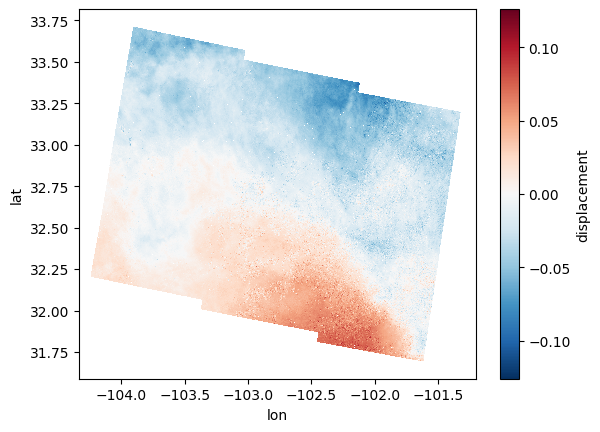

In [18]:
ds_1d.displacement.plot()

# Read Sentinel data corresponding to OPERA data

# Image for date 1

In [19]:
#s1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.tif
import rioxarray

# Open the GeoTIFF file with rioxarray (which preserves geospatial info)
tiff_file = "s1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.tif"
data = rioxarray.open_rasterio(tiff_file, masked=True)

# Assign a name to the data variable
data.name = "backscatter"

# Export to NetCDF
netcdf_file = tiff_file.replace(".tif", ".nc")
data.to_netcdf(netcdf_file)

netcdf_file

's1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.nc'

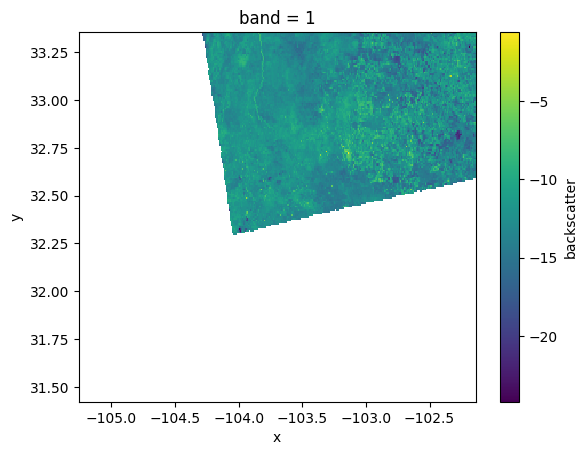

In [25]:
import xarray as xr
ds = xr.open_dataset('s1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.nc')
ds.backscatter.isel(band=0).plot()

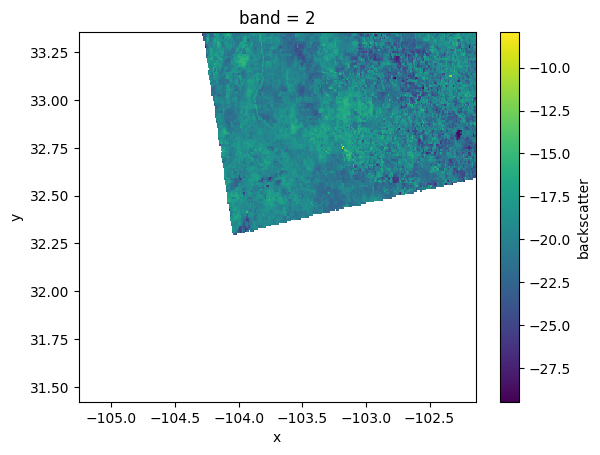

In [26]:
import xarray as xr
ds = xr.open_dataset('s1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.nc')
ds.backscatter.isel(band=1).plot()

In [23]:
#s1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.tif
import rioxarray

# Open the GeoTIFF file with rioxarray (which preserves geospatial info)
tiff_file = "s1_S1B_IW_GRDH_1SDV_20210805T005129_20210805T005154_028104_035A51_E471_2021-07-22_2021-08-21.tif"
data = rioxarray.open_rasterio(tiff_file, masked=True)

# Assign a name to the data variable
data.name = "backscatter"

# Export to NetCDF
netcdf_file = tiff_file.replace(".tif", ".nc")
data.to_netcdf(netcdf_file)

netcdf_file

's1_S1B_IW_GRDH_1SDV_20210805T005129_20210805T005154_028104_035A51_E471_2021-07-22_2021-08-21.nc'

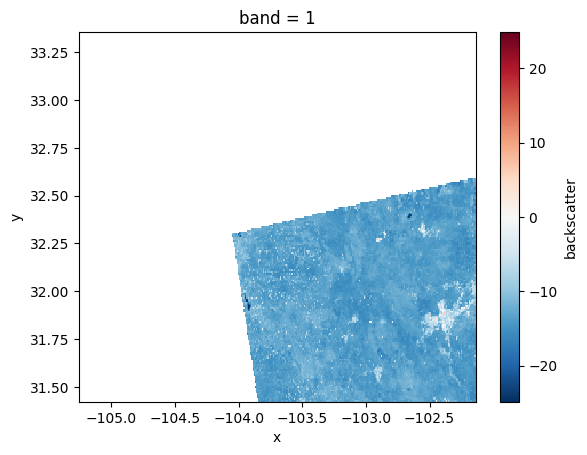

In [27]:
import xarray as xr
ds = xr.open_dataset('s1_S1B_IW_GRDH_1SDV_20210805T005129_20210805T005154_028104_035A51_E471_2021-07-22_2021-08-21.nc')
ds.backscatter.isel(band=0).plot()

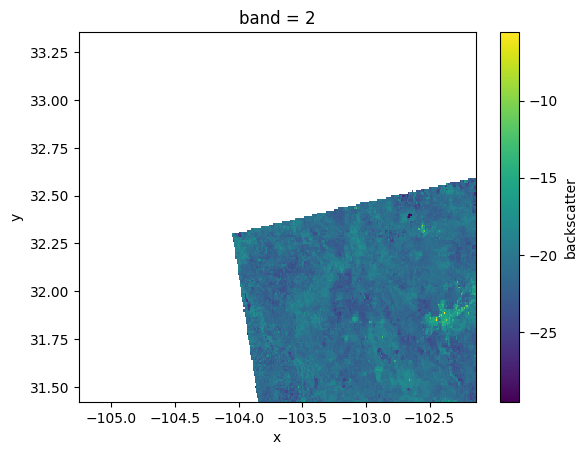

In [28]:
import xarray as xr
ds = xr.open_dataset('s1_S1B_IW_GRDH_1SDV_20210805T005129_20210805T005154_028104_035A51_E471_2021-07-22_2021-08-21.nc')
ds.backscatter.isel(band=1).plot()

# Merge band 0 for both the images for date 1

# Image for date 2

In [29]:
#s1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.tif
import rioxarray

# Open the GeoTIFF file with rioxarray (which preserves geospatial info)
tiff_file = "s1_S1B_IW_GRDH_1SDV_20211121T005131_20211121T005156_029679_038AD6_9298_2021-10-23_2021-11-22.tif"
data = rioxarray.open_rasterio(tiff_file, masked=True)

# Assign a name to the data variable
data.name = "backscatter"

# Export to NetCDF
netcdf_file = tiff_file.replace(".tif", ".nc")
data.to_netcdf(netcdf_file)

netcdf_file

's1_S1B_IW_GRDH_1SDV_20211121T005131_20211121T005156_029679_038AD6_9298_2021-10-23_2021-11-22.nc'

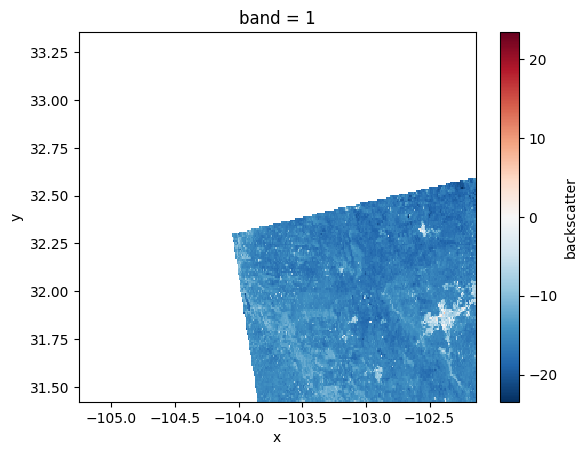

In [30]:
import xarray as xr
ds = xr.open_dataset('s1_S1B_IW_GRDH_1SDV_20211121T005131_20211121T005156_029679_038AD6_9298_2021-10-23_2021-11-22.nc')
ds.backscatter.isel(band=0).plot()

In [32]:
#s1_S1B_IW_GRDH_1SDV_20210805T005154_20210805T005219_028104_035A51_CDA3_2021-07-22_2021-08-21.tif
import rioxarray

# Open the GeoTIFF file with rioxarray (which preserves geospatial info)
tiff_file = "s1_S1B_IW_GRDH_1SDV_20211121T005156_20211121T005221_029679_038AD6_46B4_2021-10-23_2021-11-22.tif"

data = rioxarray.open_rasterio(tiff_file, masked=True)

# Assign a name to the data variable
data.name = "backscatter"

# Export to NetCDF
netcdf_file = tiff_file.replace(".tif", ".nc")
data.to_netcdf(netcdf_file)

netcdf_file

's1_S1B_IW_GRDH_1SDV_20211121T005156_20211121T005221_029679_038AD6_46B4_2021-10-23_2021-11-22.nc'

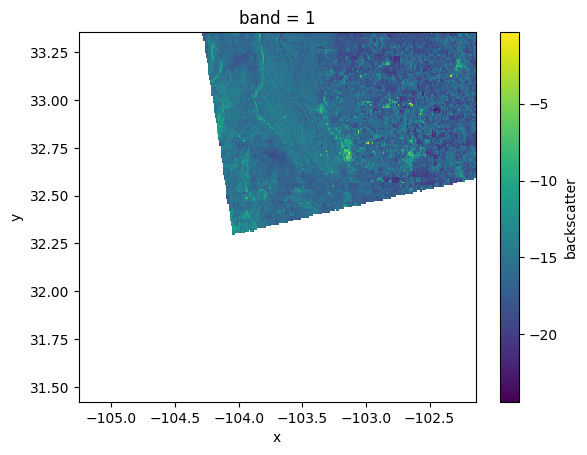

In [34]:
import xarray as xr
ds = xr.open_dataset('s1_S1B_IW_GRDH_1SDV_20211121T005156_20211121T005221_029679_038AD6_46B4_2021-10-23_2021-11-22.nc')
ds.backscatter.isel(band=0).plot()

# Merge both the images for date 2

# Bring image for date 1, image for date 2 in a single xarray dataset

# Bring both the sentinel 1 and opera data onto the same grid

# Save the netcdf file with 2 sentinel 1 images which are input and 1 opera image as target

# Train the model